## Imports

In [175]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_fscore_support, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

In [176]:
torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [177]:
DATA_PATH = './data/cmapss_data/'
WINDOW_SIZE = 30
FAILURE_WINDOW = 30
BATCH_SIZE = 64
RANDOM_SEED = 42

## Data Loading

In [178]:
def load_cmapss_data(data_path=DATA_PATH):
    """
        Load NASA CMAPSS FD001 dataset.
        
        Columns:
        - engine_id: Engine unit number
        - cycle: Operational cycle
        - setting_1, setting_2, setting_3: Operational settings
        - sensor_1 to sensor_21: Sensor measurements (21 sensors)
        
        Returns:
        - train_df: Training data with RUL computed
        - test_df: Test data 
        - rul_df: True RUL values for test engines
    """
    
    col_names = ['engine_id', 'cycle'] + \
                [f'setting_{i}' for i in range(1, 4)] + \
                [f'sensor_{i}' for i in range(1, 22)]
    
    train_df = pd.read_csv(f'{data_path}train_FD001.txt', sep=r'\s+', header=None, names=col_names)
    
    test_df = pd.read_csv(f'{data_path}test_FD001.txt', sep=r'\s+', header=None, names=col_names)
    
    rul_df = pd.read_csv(f'{data_path}RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'])
    rul_df['engine_id'] = rul_df.index + 1
    
    print(f"Train shape: {train_df.shape}")
    print(f"Test shape: {test_df.shape}")
    print(f"RUL shape: {rul_df.shape}")
    print(f"Number of train engines: {train_df['engine_id'].nunique()}")
    print(f"Number of test engines: {test_df['engine_id'].nunique()}")
    
    return train_df, test_df, rul_df

In [179]:
def compute_rul(train_df):
    """
        Compute Remaining Useful Life (RUL) for training data.
        RUL = max_cycle - current_cycle for each engine.
    """
    
    max_cycles = train_df.groupby('engine_id')['cycle'].max().reset_index()
    max_cycles.columns = ['engine_id', 'max_cycle']
    
    train_df = train_df.merge(max_cycles, on='engine_id', how='left')
    
    train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']
    
    train_df = train_df.drop('max_cycle', axis=1)
    
    return train_df

In [180]:
def add_rul_to_test(test_df, rul_df):
    """
    Add RUL to test data. 
    For test data, RUL at last cycle = true RUL from RUL_FD001.txt
    For earlier cycles, RUL = true_RUL + (max_cycle - current_cycle)
    """
    
    max_cycles_test = test_df.groupby('engine_id')['cycle'].max().reset_index()
    max_cycles_test.columns = ['engine_id', 'max_cycle_test']
    
    max_cycles_test = max_cycles_test.merge(rul_df, on='engine_id', how='left')
    max_cycles_test = max_cycles_test.rename(columns={'RUL': 'RUL_at_last'})
    
    test_df = test_df.merge(max_cycles_test[['engine_id', 'max_cycle_test', 'RUL_at_last']], on='engine_id', how='left')
    
    test_df['RUL'] = test_df['RUL_at_last'] + (test_df['max_cycle_test'] - test_df['cycle'])
    
    test_df = test_df.drop(['max_cycle_test', 'RUL_at_last'], axis=1)
    
    return test_df

In [181]:
print("Loading NASA CMAPSS FD001 dataset")
train_df, test_df, rul_df = load_cmapss_data()

train_df = compute_rul(train_df)

test_df = add_rul_to_test(test_df, rul_df)

print(f"\nTrain RUL range: {train_df['RUL'].min()} - {train_df['RUL'].max()}")
print(f"Test RUL range: {test_df['RUL'].min()} - {test_df['RUL'].max()}")

print("\nSample training data (engine 1, first 5 cycles):")
print(train_df[train_df['engine_id'] == 1].head())
print("\nSample test data (engine 1, last 5 cycles):")
print(test_df[test_df['engine_id'] == 1].tail())

Loading NASA CMAPSS FD001 dataset
Train shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100, 2)
Number of train engines: 100
Number of test engines: 100

Train RUL range: 0 - 361
Test RUL range: 7 - 340

Sample training data (engine 1, first 5 cycles):
   engine_id  cycle  setting_1  setting_2  setting_3  sensor_1  sensor_2  \
0          1      1    -0.0007    -0.0004      100.0    518.67    641.82   
1          1      2     0.0019    -0.0003      100.0    518.67    642.15   
2          1      3    -0.0043     0.0003      100.0    518.67    642.35   
3          1      4     0.0007     0.0000      100.0    518.67    642.35   
4          1      5    -0.0019    -0.0002      100.0    518.67    642.37   

   sensor_3  sensor_4  sensor_5  ...  sensor_13  sensor_14  sensor_15  \
0   1589.70   1400.60     14.62  ...    2388.02    8138.62     8.4195   
1   1591.82   1403.14     14.62  ...    2388.07    8131.49     8.4318   
2   1587.99   1404.20     14.62  ...    2388.03    8133.23     8

## Exploratory Data Analysis

In [182]:
train_df, test_df, rul_df = load_cmapss_data(DATA_PATH)

train_df = compute_rul(train_df)

test_df = add_rul_to_test(test_df, rul_df)

# Identify constant sensors (zero variance) and drop them
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
setting_cols = [f'setting_{i}' for i in range(1, 4)]
feature_cols = setting_cols + sensor_cols

constant_sensors = []
for col in sensor_cols:
    if train_df[col].std() == 0:
        constant_sensors.append(col)
        print(f"Constant sensor (dropping): {col}")

feature_cols = [c for c in feature_cols if c not in constant_sensors]
print(f"\nFeatures used ({len(feature_cols)}): {feature_cols}")

Train shape: (20631, 26)
Test shape: (13096, 26)
RUL shape: (100, 2)
Number of train engines: 100
Number of test engines: 100
Constant sensor (dropping): sensor_1
Constant sensor (dropping): sensor_10
Constant sensor (dropping): sensor_18
Constant sensor (dropping): sensor_19

Features used (20): ['setting_1', 'setting_2', 'setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_20', 'sensor_21']


In [183]:
# Normalize features using StandardScaler fitted on training data
scaler = StandardScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

In [184]:
def create_sequences(df, feature_cols, window_size, failure_window):
    """
    Create sliding window sequences from engine run-to-failure data.
    
    Returns:
    - X: (num_sequences, window_size, num_features)
    - y_rul: (num_sequences,) - RUL at the end of each window
    - y_class: (num_sequences,) - Binary label (1 if RUL <= failure_window)
    """
    sequences = []
    rul_labels = []
    class_labels = []
    
    for engine_id in df['engine_id'].unique():
        engine_data = df[df['engine_id'] == engine_id].sort_values('cycle')
        features = engine_data[feature_cols].values
        rul_values = engine_data['RUL'].values
        
        for i in range(len(features) - window_size + 1):
            seq = features[i:i+window_size]
            rul = rul_values[i + window_size - 1]
            class_label = 1 if rul <= failure_window else 0
            
            sequences.append(seq)
            rul_labels.append(rul)
            class_labels.append(class_label)
    
    return np.array(sequences), np.array(rul_labels), np.array(class_labels)

In [185]:
print("\nCreating training sequences")
X_train_seq, y_train_rul, y_train_class = create_sequences(
    train_df, feature_cols, WINDOW_SIZE, FAILURE_WINDOW
)
print(f"Training sequences: {X_train_seq.shape}")
print(f"RUL labels: {y_train_rul.shape}, range: [{y_train_rul.min()}, {y_train_rul.max()}]")
print(f"Class labels: {y_train_class.shape}, positive rate: {y_train_class.mean():.3f}")


Creating training sequences
Training sequences: (17731, 30, 20)
RUL labels: (17731,), range: [0, 332]
Class labels: (17731,), positive rate: 0.175


In [186]:
def create_test_sequences(test_df, feature_cols, window_size):
    """
    For test data, we only take the last window of each engine
    (since test data doesn't have full run-to-failure trajectories)
    """
    sequences = []
    engine_ids = []
    
    for engine_id in test_df['engine_id'].unique():
        engine_data = test_df[test_df['engine_id'] == engine_id].sort_values('cycle')
        features = engine_data[feature_cols].values
        
        # Take the last window
        if len(features) >= window_size:
            seq = features[-window_size:]
        else:
            # Pad if needed (shouldn't happen for FD001)
            pad_len = window_size - len(features)
            seq = np.pad(features, ((pad_len, 0), (0, 0)), mode='edge')
        
        sequences.append(seq)
        engine_ids.append(engine_id)
    
    return np.array(sequences), np.array(engine_ids)

In [187]:
print("\nCreating test sequences")
X_test_seq, test_engine_ids = create_test_sequences(test_df, feature_cols, WINDOW_SIZE)
print(f"Test sequences: {X_test_seq.shape}")


Creating test sequences
Test sequences: (100, 30, 20)


In [188]:
y_test_rul = rul_df.set_index('engine_id').loc[test_engine_ids, 'RUL'].values
y_test_class = (y_test_rul <= FAILURE_WINDOW).astype(int)

print(f"Test RUL labels: {y_test_rul.shape}, range: [{y_test_rul.min()}, {y_test_rul.max()}]")
print(f"Test class labels: {y_test_class.shape}, positive rate: {y_test_class.mean():.3f}")

Test RUL labels: (100,), range: [7, 145]
Test class labels: (100,), positive rate: 0.250


In [189]:
train_engine_ids = train_df['engine_id'].unique()
val_engine_ids = np.random.choice(train_engine_ids, size=int(0.2 * len(train_engine_ids)), replace=False)
train_engine_ids = np.setdiff1d(train_engine_ids, val_engine_ids)

train_mask = np.isin(np.repeat(train_df['engine_id'].unique(), 
                               [len(train_df[train_df['engine_id']==eid]) - WINDOW_SIZE + 1 
                                for eid in train_df['engine_id'].unique()]), train_engine_ids)
val_mask = ~train_mask

def get_engine_for_sequence(df, feature_cols, window_size):
    """Get engine ID for each sequence"""
    engine_ids = []
    for engine_id in df['engine_id'].unique():
        engine_data = df[df['engine_id'] == engine_id].sort_values('cycle')
        n_seq = len(engine_data) - window_size + 1
        engine_ids.extend([engine_id] * n_seq)
    return np.array(engine_ids)

train_seq_engine_ids = get_engine_for_sequence(train_df, feature_cols, WINDOW_SIZE)
train_mask = np.isin(train_seq_engine_ids, train_engine_ids)
val_mask = np.isin(train_seq_engine_ids, val_engine_ids)

X_train = X_train_seq[train_mask]
y_train_rul_split = y_train_rul[train_mask]
y_train_class_split = y_train_class[train_mask]

X_val = X_train_seq[val_mask]
y_val_rul = y_train_rul[val_mask]
y_val_class = y_train_class[val_mask]

print(f"\nTrain set: {X_train.shape[0]} sequences")
print(f"Val set: {X_val.shape[0]} sequences")
print(f"Test set: {X_test_seq.shape[0]} sequences")


Train set: 14241 sequences
Val set: 3490 sequences
Test set: 100 sequences


In [190]:
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_rul_tensor = torch.FloatTensor(y_train_rul_split).to(device)
y_train_class_tensor = torch.FloatTensor(y_train_class_split).to(device)

X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_rul_tensor = torch.FloatTensor(y_val_rul).to(device)
y_val_class_tensor = torch.FloatTensor(y_val_class).to(device)

X_test_tensor = torch.FloatTensor(X_test_seq).to(device)
y_test_rul_tensor = torch.FloatTensor(y_test_rul).to(device)
y_test_class_tensor = torch.FloatTensor(y_test_class).to(device)

In [191]:
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_rul_tensor, y_train_class_tensor)
val_dataset = torch.utils.data.TensorDataset(X_val_tensor, y_val_rul_tensor, y_val_class_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_rul_tensor, y_test_class_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

DataLoaders created:
  Train batches: 223
  Val batches: 55
  Test batches: 2


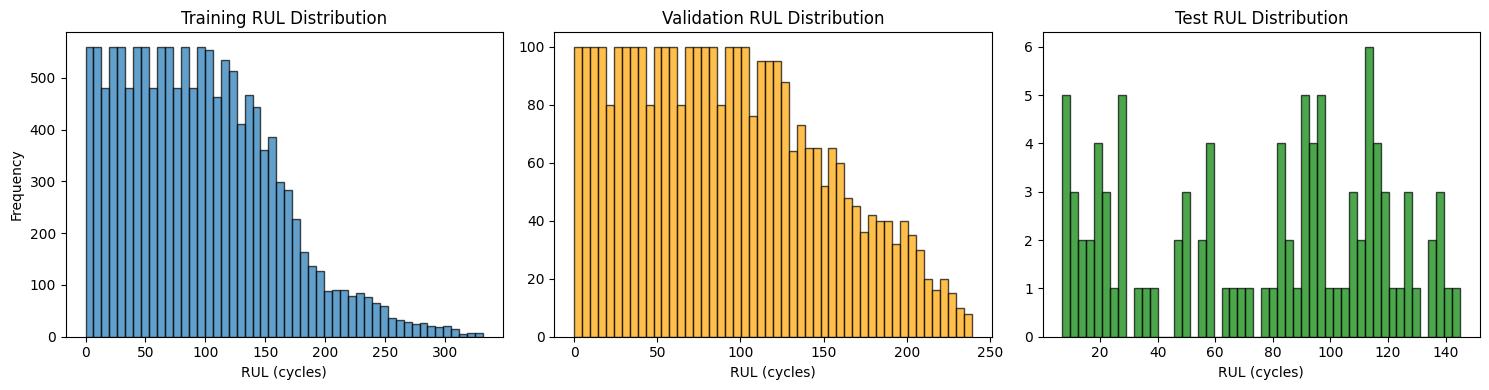

In [192]:
# Visualize class distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(y_train_rul_split, bins=50, alpha=0.7, edgecolor='black')
axes[0].set_title('Training RUL Distribution')
axes[0].set_xlabel('RUL (cycles)')
axes[0].set_ylabel('Frequency')

axes[1].hist(y_val_rul, bins=50, alpha=0.7, edgecolor='black', color='orange')
axes[1].set_title('Validation RUL Distribution')
axes[1].set_xlabel('RUL (cycles)')

axes[2].hist(y_test_rul, bins=50, alpha=0.7, edgecolor='black', color='green')
axes[2].set_title('Test RUL Distribution')
axes[2].set_xlabel('RUL (cycles)')

plt.tight_layout()
plt.show()

In [193]:
print(f"\nClass Distribution:")
print(f"  Train: {y_train_class_split.mean():.3f} positive (failure within {FAILURE_WINDOW} cycles)")
print(f"  Val: {y_val_class.mean():.3f} positive")
print(f"  Test: {y_test_class.mean():.3f} positive")


Class Distribution:
  Train: 0.174 positive (failure within 30 cycles)
  Val: 0.178 positive
  Test: 0.250 positive


## Model Definitions

In [194]:
INPUT_DIM = X_train_tensor.shape[2]
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.3
OUTPUT_DIM_RUL = 1
OUTPUT_DIM_CLASS = 1

print(f"Input dimension: {INPUT_DIM}")
print(f"Window size: {WINDOW_SIZE}")
print(f"Hidden dim: {HIDDEN_DIM}")
print(f"Num layers: {NUM_LAYERS}")

Input dimension: 20
Window size: 30
Hidden dim: 128
Num layers: 2


In [195]:
class LSTMRULPredictor(nn.Module):
    
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, output_dim_rul=1, output_dim_class=1):
        super(LSTMRULPredictor, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0,
            bidirectional=False
        )
        
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )
        
        self.shared_fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        self.rul_head = nn.Sequential(
            nn.Linear(hidden_dim // 4, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, output_dim_rul)
        )
        
        self.class_head = nn.Sequential(
            nn.Linear(hidden_dim // 4, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, output_dim_class),
            nn.Sigmoid()
        )
    
    def attention_net(self, lstm_output):
        """Apply attention mechanism to LSTM outputs"""
        attn_weights = self.attention(lstm_output)
        attn_weights = F.softmax(attn_weights, dim=1)
        context = torch.sum(attn_weights * lstm_output, dim=1)
        return context, attn_weights
    
    def forward(self, x):
        batch_size = x.size(0)
        
        lstm_out, (h_n, c_n) = self.lstm(x)
        
        context, attn_weights = self.attention_net(lstm_out)
        
        shared_features = self.shared_fc(context)
        
        rul_pred = self.rul_head(shared_features)
        class_pred = self.class_head(shared_features)
        
        return rul_pred.squeeze(-1), class_pred.squeeze(-1), attn_weights

In [196]:
class GRURULPredictor(nn.Module):
    
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, output_dim_rul=1, output_dim_class=1):
        super(GRURULPredictor, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.gru = nn.GRU(
            input_dim, hidden_dim, num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0,
            bidirectional=False
        )
        
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )
        
        self.shared_fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        self.rul_head = nn.Sequential(
            nn.Linear(hidden_dim // 4, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, output_dim_rul)
        )
        
        self.class_head = nn.Sequential(
            nn.Linear(hidden_dim // 4, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, output_dim_class),
            nn.Sigmoid()
        )
    
    def attention_net(self, gru_output):
        attn_weights = self.attention(gru_output)
        attn_weights = F.softmax(attn_weights, dim=1)
        context = torch.sum(attn_weights * gru_output, dim=1)
        return context, attn_weights
    
    def forward(self, x):
        gru_out, h_n = self.gru(x)
        context, attn_weights = self.attention_net(gru_out)
        shared_features = self.shared_fc(context)
        rul_pred = self.rul_head(shared_features)
        class_pred = self.class_head(shared_features)
        return rul_pred.squeeze(-1), class_pred.squeeze(-1), attn_weights


In [197]:
class TCNRULPredictor(nn.Module):
    
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, output_dim_rul=1, output_dim_class=1):
        super(TCNRULPredictor, self).__init__()
        
        layers = []
        for i in range(num_layers):
            dilation = 2 ** i
            in_channels = input_dim if i == 0 else hidden_dim
            layers.append(nn.Conv1d(
                in_channels, hidden_dim, kernel_size=3,
                padding=dilation, dilation=dilation
            ))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
        
        self.tcn = nn.Sequential(*layers)
        
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        self.shared_fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        self.rul_head = nn.Sequential(
            nn.Linear(hidden_dim // 4, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, output_dim_rul)
        )
        
        self.class_head = nn.Sequential(
            nn.Linear(hidden_dim // 4, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, output_dim_class),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        x = x.transpose(1, 2)
    
        tcn_out = self.tcn(x)
        
        pooled = self.global_pool(tcn_out).squeeze(-1)
        
        shared_features = self.shared_fc(pooled)
        
        rul_pred = self.rul_head(shared_features)
        class_pred = self.class_head(shared_features)
        
        return rul_pred.squeeze(-1), class_pred.squeeze(-1), None

In [198]:
# Initialize models
lstm_model = LSTMRULPredictor(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
gru_model = GRURULPredictor(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
tcn_model = TCNRULPredictor(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)

# Count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"LSTM Model Parameters: {count_parameters(lstm_model):,}")
print(f"GRU Model Parameters: {count_parameters(gru_model):,}")
print(f"TCN Model Parameters: {count_parameters(tcn_model):,}")

LSTM Model Parameters: 228,643
GRU Model Parameters: 176,419
TCN Model Parameters: 69,026


## Joint Loss Function

In [199]:
class JointLoss(nn.Module):
    """
    Joint loss for multi-task learning:
    - Regression: MSE Loss for RUL prediction
    - Classification: BCE Loss for failure prediction
    - Weighted combination with optional uncertainty weighting
    """
    
    def __init__(self, alpha=1.0, beta=1.0, use_uncertainty_weighting=False):
        super(JointLoss, self).__init__()
        self.alpha = alpha  # Weight for regression loss
        self.beta = beta    # Weight for classification loss
        self.use_uncertainty_weighting = use_uncertainty_weighting
        
        self.mse_loss = nn.MSELoss()
        self.bce_loss = nn.BCELoss()
        
        if use_uncertainty_weighting:
            self.log_var_rul = nn.Parameter(torch.zeros(1))
            self.log_var_class = nn.Parameter(torch.zeros(1))
    
    def forward(self, rul_pred, class_pred, rul_target, class_target):

        loss_rul = self.mse_loss(rul_pred, rul_target)
        
        loss_class = self.bce_loss(class_pred, class_target)
        
        if self.use_uncertainty_weighting:
            # Uncertainty weighting: loss = 1/(2*sigma^2) * L + log(sigma)
            precision_rul = torch.exp(-self.log_var_rul)
            precision_class = torch.exp(-self.log_var_class)
            
            loss = (precision_rul * loss_rul + self.log_var_rul + 
                    precision_class * loss_class + self.log_var_class)
        else:
            # Fixed weighting
            loss = self.alpha * loss_rul + self.beta * loss_class
        
        return loss, loss_rul, loss_class


## Training Utilities

In [200]:
def train_epoch(model, loader, optimizer, criterion, device, clip_grad=1.0):
    model.train()
    total_loss = 0
    total_rul_loss = 0
    total_class_loss = 0
    num_batches = 0
    
    for X_batch, y_rul_batch, y_class_batch in loader:
        X_batch = X_batch.to(device)
        y_rul_batch = y_rul_batch.to(device)
        y_class_batch = y_class_batch.to(device)
        
        optimizer.zero_grad()
        
        rul_pred, class_pred, _ = model(X_batch)
        
        loss, loss_rul, loss_class = criterion(rul_pred, class_pred, y_rul_batch, y_class_batch)
        
        loss.backward()
        
        if clip_grad > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
        
        optimizer.step()
        
        total_loss += loss.item()
        total_rul_loss += loss_rul.item()
        total_class_loss += loss_class.item()
        num_batches += 1
    
    return (total_loss / num_batches, 
            total_rul_loss / num_batches, 
            total_class_loss / num_batches)

In [201]:
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    total_rul_loss = 0
    total_class_loss = 0
    num_batches = 0
    
    all_rul_preds = []
    all_rul_targets = []
    all_class_preds = []
    all_class_targets = []
    
    with torch.no_grad():
        for X_batch, y_rul_batch, y_class_batch in loader:
            X_batch = X_batch.to(device)
            y_rul_batch = y_rul_batch.to(device)
            y_class_batch = y_class_batch.to(device)
            
            rul_pred, class_pred, _ = model(X_batch)
            
            loss, loss_rul, loss_class = criterion(rul_pred, class_pred, y_rul_batch, y_class_batch)
            
            total_loss += loss.item()
            total_rul_loss += loss_rul.item()
            total_class_loss += loss_class.item()
            num_batches += 1
            
            all_rul_preds.append(rul_pred.cpu().numpy())
            all_rul_targets.append(y_rul_batch.cpu().numpy())
            all_class_preds.append(class_pred.cpu().numpy())
            all_class_targets.append(y_class_batch.cpu().numpy())
    
    all_rul_preds = np.concatenate(all_rul_preds)
    all_rul_targets = np.concatenate(all_rul_targets)
    all_class_preds = np.concatenate(all_class_preds)
    all_class_targets = np.concatenate(all_class_targets)
    
    return (total_loss / num_batches,
            total_rul_loss / num_batches,
            total_class_loss / num_batches,
            all_rul_preds, all_rul_targets,
            all_class_preds, all_class_targets)

In [202]:
def compute_metrics(rul_preds, rul_targets, class_preds, class_targets, threshold=0.5):

    # Regression metrics
    mse = mean_squared_error(rul_targets, rul_preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(rul_targets, rul_preds)
    r2 = r2_score(rul_targets, rul_preds)
    
    # Classification metrics
    class_preds_binary = (class_preds > threshold).astype(int)
    accuracy = accuracy_score(class_targets, class_preds_binary)
    precision, recall, f1, _ = precision_recall_fscore_support(
        class_targets, class_preds_binary, average='binary', zero_division=0
    )
    try:
        auc = roc_auc_score(class_targets, class_preds)
    except:
        auc = 0.0
    
    return {
        'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2,
        'accuracy': accuracy, 'precision': precision, 
        'recall': recall, 'f1': f1, 'auc': auc
    }

## Training Loop

In [203]:
criterion = JointLoss(alpha=1.0, beta=1.0, use_uncertainty_weighting=True).to(device)

optimizers = {
    'LSTM': torch.optim.AdamW(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4),
    'GRU': torch.optim.AdamW(gru_model.parameters(), lr=1e-3, weight_decay=1e-4),
    'TCN': torch.optim.AdamW(tcn_model.parameters(), lr=1e-3, weight_decay=1e-4)
}

schedulers = {
    'LSTM': torch.optim.lr_scheduler.ReduceLROnPlateau(optimizers['LSTM'], mode='min', factor=0.5, patience=5),
    'GRU': torch.optim.lr_scheduler.ReduceLROnPlateau(optimizers['GRU'], mode='min', factor=0.5, patience=5),
    'TCN': torch.optim.lr_scheduler.ReduceLROnPlateau(optimizers['TCN'], mode='min', factor=0.5, patience=5)
}

models = {
    'LSTM': lstm_model,
    'GRU': gru_model,
    'TCN': tcn_model
}

histories = {}

patience = 15
best_val_loss = {name: float('inf') for name in models}
patience_counter = {name: 0 for name in models}

NUM_EPOCHS = 100

print("STARTING TRAINING")

for name, model in models.items():
    print(f"Training {name} Model")
    
    optimizer = optimizers[name]
    scheduler = schedulers[name]
    
    history = {
        'train_loss': [], 'val_loss': [],
        'train_rul_loss': [], 'val_rul_loss': [],
        'train_class_loss': [], 'val_class_loss': [],
        'val_rmse': [], 'val_mae': [], 'val_r2': [],
        'val_accuracy': [], 'val_precision': [], 'val_recall': [], 'val_f1': [], 'val_auc': []
    }
    
    for epoch in range(NUM_EPOCHS):
        model.train()
        train_losses = []
        train_rul_losses = []
        train_class_losses = []
        
        for batch_X, batch_y_rul, batch_y_class in train_loader:
            optimizer.zero_grad()
            
            rul_pred, class_pred, _ = model(batch_X)
            
            loss, loss_rul, loss_class = criterion(rul_pred, class_pred, batch_y_rul, batch_y_class)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_losses.append(loss.item())
            train_rul_losses.append(loss_rul.item())
            train_class_losses.append(loss_class.item())
        
        model.eval()
        val_losses = []
        val_rul_losses = []
        val_class_losses = []
        all_rul_preds = []
        all_rul_targets = []
        all_class_preds = []
        all_class_targets = []
        
        with torch.no_grad():
            for batch_X, batch_y_rul, batch_y_class in val_loader:
                rul_pred, class_pred, _ = model(batch_X)
                
                loss, loss_rul, loss_class = criterion(rul_pred, class_pred, batch_y_rul, batch_y_class)
                
                val_losses.append(loss.item())
                val_rul_losses.append(loss_rul.item())
                val_class_losses.append(loss_class.item())
                
                all_rul_preds.append(rul_pred.cpu().numpy())
                all_rul_targets.append(batch_y_rul.cpu().numpy())
                all_class_preds.append(class_pred.cpu().numpy())
                all_class_targets.append(batch_y_class.cpu().numpy())
        
        all_rul_preds = np.concatenate(all_rul_preds)
        all_rul_targets = np.concatenate(all_rul_targets)
        all_class_preds = np.concatenate(all_class_preds)
        all_class_targets = np.concatenate(all_class_targets)
        
        val_rmse = np.sqrt(mean_squared_error(all_rul_targets, all_rul_preds))
        val_mae = mean_absolute_error(all_rul_targets, all_rul_preds)
        val_r2 = r2_score(all_rul_targets, all_rul_preds)
        
        class_preds_binary = (all_class_preds > 0.5).astype(int)
        val_accuracy = accuracy_score(all_class_targets, class_preds_binary)
        val_precision = precision_score(all_class_targets, class_preds_binary, zero_division=0)
        val_recall = recall_score(all_class_targets, class_preds_binary, zero_division=0)
        val_f1 = f1_score(all_class_targets, class_preds_binary, zero_division=0)
        val_auc = roc_auc_score(all_class_targets, all_class_preds)
        
        history['train_loss'].append(np.mean(train_losses))
        history['val_loss'].append(np.mean(val_losses))
        history['train_rul_loss'].append(np.mean(train_rul_losses))
        history['val_rul_loss'].append(np.mean(val_rul_losses))
        history['train_class_loss'].append(np.mean(train_class_losses))
        history['val_class_loss'].append(np.mean(val_class_losses))
        history['val_rmse'].append(val_rmse)
        history['val_mae'].append(val_mae)
        history['val_r2'].append(val_r2)
        history['val_accuracy'].append(val_accuracy)
        history['val_precision'].append(val_precision)
        history['val_recall'].append(val_recall)
        history['val_f1'].append(val_f1)
        history['val_auc'].append(val_auc)
        
        scheduler.step(np.mean(val_losses))
        
        if np.mean(val_losses) < best_val_loss[name]:
            best_val_loss[name] = np.mean(val_losses)
            patience_counter[name] = 0
            torch.save(model.state_dict(), f'best_{name.lower()}_model.pth')
        else:
            patience_counter[name] += 1
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
                  f"Train Loss: {np.mean(train_losses):.4f} (RUL: {np.mean(train_rul_losses):.4f}, Class: {np.mean(train_class_losses):.4f}) | "
                  f"Val Loss: {np.mean(val_losses):.4f} (RUL: {np.mean(val_rul_losses):.4f}, Class: {np.mean(val_class_losses):.4f}) | "
                  f"RMSE: {val_rmse:.2f} | MAE: {val_mae:.2f} | R²: {val_r2:.4f} | "
                  f"Acc: {val_accuracy:.4f} | F1: {val_f1:.4f} | AUC: {val_auc:.4f}")
        
        if patience_counter[name] >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    model.load_state_dict(torch.load(f'best_{name.lower()}_model.pth'))
    histories[name] = history
    print(f"\n{name} training completed. Best val loss: {best_val_loss[name]:.4f}\n")

print("ALL MODELS TRAINED")

STARTING TRAINING
Training LSTM Model


Epoch   1/100 | Train Loss: 5787.6246 (RUL: 5787.1397, Class: 0.4849) | Val Loss: 1183.4810 (RUL: 1183.2098, Class: 0.2712) | RMSE: 34.54 | MAE: 24.92 | R²: 0.6483 | Acc: 0.8223 | F1: 0.0000 | AUC: 0.9780
Epoch   5/100 | Train Loss: 2055.7867 (RUL: 2055.5555, Class: 0.2312) | Val Loss: 752.6244 (RUL: 752.3940, Class: 0.2304) | RMSE: 27.54 | MAE: 19.47 | R²: 0.7764 | Acc: 0.8249 | F1: 0.0286 | AUC: 0.9924
Epoch  10/100 | Train Loss: 1588.1836 (RUL: 1588.0012, Class: 0.1823) | Val Loss: 737.0469 (RUL: 736.8673, Class: 0.1797) | RMSE: 27.26 | MAE: 18.39 | R²: 0.7810 | Acc: 0.9040 | F1: 0.6298 | AUC: 0.9945
Epoch  15/100 | Train Loss: 1290.2242 (RUL: 1290.0661, Class: 0.1581) | Val Loss: 906.8413 (RUL: 906.7075, Class: 0.1338) | RMSE: 30.24 | MAE: 19.89 | R²: 0.7305 | Acc: 0.9332 | F1: 0.7718 | AUC: 0.9943
Early stopping at epoch 19

LSTM training completed. Best val loss: 595.4002

Training GRU Model
Epoch   1/100 | Train Loss: 6063.0093 (RUL: 6062.5679, Class: 0.4414) | Val Loss: 1554.58

## Evaluation on Test Set

In [204]:
test_results = {}

print("TEST SET EVALUATION")

for name, model in models.items():
    model.eval()
    
    all_rul_preds = []
    all_rul_targets = []
    all_class_preds = []
    all_class_targets = []
    
    with torch.no_grad():
        for batch_X, batch_y_rul, batch_y_class in test_loader:
            rul_pred, class_pred, _ = model(batch_X)
            
            all_rul_preds.append(rul_pred.cpu().numpy())
            all_rul_targets.append(batch_y_rul.cpu().numpy())
            all_class_preds.append(class_pred.cpu().numpy())
            all_class_targets.append(batch_y_class.cpu().numpy())
    
    all_rul_preds = np.concatenate(all_rul_preds)
    all_rul_targets = np.concatenate(all_rul_targets)
    all_class_preds = np.concatenate(all_class_preds)
    all_class_targets = np.concatenate(all_class_targets)
    
    rmse = np.sqrt(mean_squared_error(all_rul_targets, all_rul_preds))
    mae = mean_absolute_error(all_rul_targets, all_rul_preds)
    r2 = r2_score(all_rul_targets, all_rul_preds)
    
    class_preds_binary = (all_class_preds > 0.5).astype(int)
    accuracy = accuracy_score(all_class_targets, class_preds_binary)
    precision = precision_score(all_class_targets, class_preds_binary, zero_division=0)
    recall = recall_score(all_class_targets, class_preds_binary, zero_division=0)
    f1 = f1_score(all_class_targets, class_preds_binary, zero_division=0)
    auc = roc_auc_score(all_class_targets, all_class_preds)
    
    test_results[name] = {
        'metrics': {
            'rmse': rmse,
            'mae': mae,
            'r2': r2,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'auc': auc
        },
        'rul_preds': all_rul_preds,
        'rul_targets': all_rul_targets,
        'class_preds': all_class_preds,
        'class_targets': all_class_targets
    }
    
    print(f"\n{name} Test Results:")
    print(f"  RUL Regression:  RMSE={rmse:.2f}  MAE={mae:.2f}  R²={r2:.4f}")
    print(f"  Classification:  Acc={accuracy:.4f}  Prec={precision:.4f}  Rec={recall:.4f}  F1={f1:.4f}  AUC={auc:.4f}")

print("TEST SET SUMMARY")
print("-"*80)
print(f"{'Model':<8} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'AUC':>8}")
print("-"*80)
for name, result in test_results.items():
    m = result['metrics']
    print(f"{name:<8} {m['rmse']:>8.2f} {m['mae']:>8.2f} {m['r2']:>8.4f} "
          f"{m['accuracy']:>8.4f} {m['precision']:>8.4f} {m['recall']:>8.4f} {m['f1']:>8.4f} {m['auc']:>8.4f}")

best_model_name = min(test_results.keys(), key=lambda k: test_results[k]['metrics']['rmse'])
print(f"\nBest model (by RMSE): {best_model_name}")

TEST SET EVALUATION

LSTM Test Results:
  RUL Regression:  RMSE=19.74  MAE=14.27  R²=0.7744
  Classification:  Acc=0.7500  Prec=0.0000  Rec=0.0000  F1=0.0000  AUC=0.9915

GRU Test Results:
  RUL Regression:  RMSE=24.35  MAE=18.08  R²=0.6566
  Classification:  Acc=0.7500  Prec=0.0000  Rec=0.0000  F1=0.0000  AUC=0.9909

TCN Test Results:
  RUL Regression:  RMSE=24.93  MAE=18.06  R²=0.6400
  Classification:  Acc=0.7500  Prec=0.0000  Rec=0.0000  F1=0.0000  AUC=0.9488
TEST SET SUMMARY
--------------------------------------------------------------------------------
Model        RMSE      MAE       R²      Acc     Prec      Rec       F1      AUC
--------------------------------------------------------------------------------
LSTM        19.74    14.27   0.7744   0.7500   0.0000   0.0000   0.0000   0.9915
GRU         24.35    18.08   0.6566   0.7500   0.0000   0.0000   0.0000   0.9909
TCN         24.93    18.06   0.6400   0.7500   0.0000   0.0000   0.0000   0.9488

Best model (by RMSE): LSTM


## Training History Visualisation

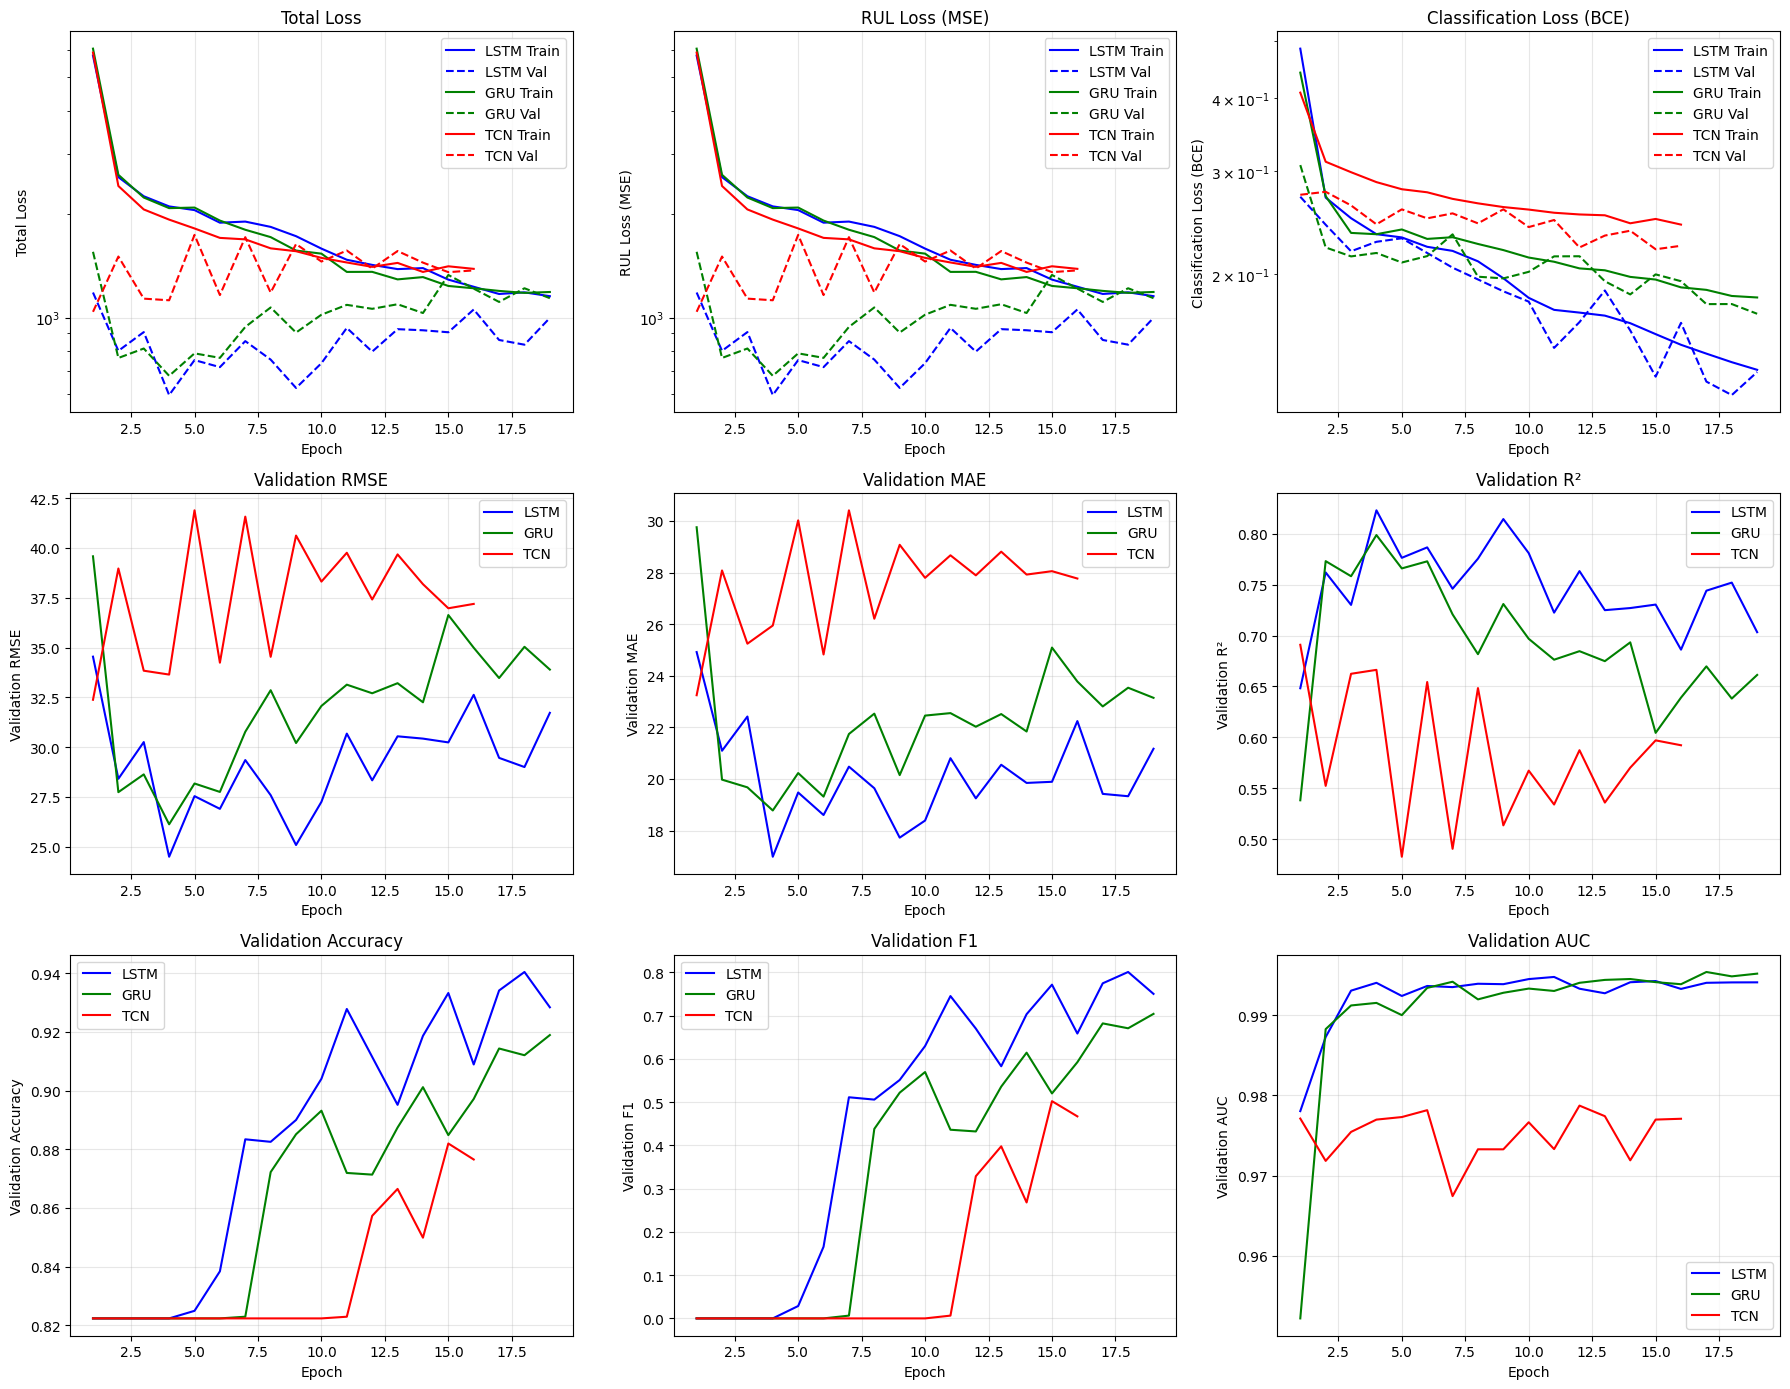

FINAL VALIDATION METRICS COMPARISON
--------------------------------------------------------------------------------
Model      Val Loss   Val RMSE    Val MAE     Val R²    Val Acc     Val F1    Val AUC
--------------------------------------------------------------------------------
LSTM       998.4960      31.72      21.17     0.7034     0.9284     0.7505     0.9941
GRU       1139.4575      33.90      23.14     0.6614     0.9189     0.7043     0.9952
TCN       1372.4873      37.19      27.77     0.5923     0.8765     0.4672     0.9771


In [205]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for name, history in histories.items():
    epochs_range = range(1, len(history['train_loss']) + 1)
    color = {'LSTM': 'blue', 'GRU': 'green', 'TCN': 'red'}[name]
    
    # Total loss
    axes[0, 0].plot(epochs_range, history['train_loss'], label=f'{name} Train', color=color, linestyle='-')
    axes[0, 0].plot(epochs_range, history['val_loss'], label=f'{name} Val', color=color, linestyle='--')
    
    # RUL loss
    axes[0, 1].plot(epochs_range, history['train_rul_loss'], label=f'{name} Train', color=color, linestyle='-')
    axes[0, 1].plot(epochs_range, history['val_rul_loss'], label=f'{name} Val', color=color, linestyle='--')
    
    # Classification loss
    axes[0, 2].plot(epochs_range, history['train_class_loss'], label=f'{name} Train', color=color, linestyle='-')
    axes[0, 2].plot(epochs_range, history['val_class_loss'], label=f'{name} Val', color=color, linestyle='--')
    
    # RMSE
    axes[1, 0].plot(epochs_range, history['val_rmse'], label=name, color=color)
    
    # MAE
    axes[1, 1].plot(epochs_range, history['val_mae'], label=name, color=color)
    
    # R²
    axes[1, 2].plot(epochs_range, history['val_r2'], label=name, color=color)
    
    # Accuracy
    axes[2, 0].plot(epochs_range, history['val_accuracy'], label=name, color=color)
    
    # F1
    axes[2, 1].plot(epochs_range, history['val_f1'], label=name, color=color)
    
    # AUC
    axes[2, 2].plot(epochs_range, history['val_auc'], label=name, color=color)

titles = ['Total Loss', 'RUL Loss (MSE)', 'Classification Loss (BCE)', 
          'Validation RMSE', 'Validation MAE', 'Validation R²',
          'Validation Accuracy', 'Validation F1', 'Validation AUC']

for i, (ax, title) in enumerate(zip(axes.flat, titles)):
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    if 'Loss' in title:
        ax.set_yscale('log')

plt.tight_layout()
plt.show()

print("FINAL VALIDATION METRICS COMPARISON")
print("-"*80)
print(f"{'Model':<8} {'Val Loss':>10} {'Val RMSE':>10} {'Val MAE':>10} {'Val R²':>10} {'Val Acc':>10} {'Val F1':>10} {'Val AUC':>10}")
print("-"*80)
for name, history in histories.items():
    print(f"{name:<8} {history['val_loss'][-1]:>10.4f} {history['val_rmse'][-1]:>10.2f} "
          f"{history['val_mae'][-1]:>10.2f} {history['val_r2'][-1]:>10.4f} "
          f"{history['val_accuracy'][-1]:>10.4f} {history['val_f1'][-1]:>10.4f} {history['val_auc'][-1]:>10.4f}")